In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp
from mat4py import loadmat

In [5]:
data1=loadmat('SVM_Data1.mat')
data2=loadmat('SVM_Data2.mat')
data3=loadmat('SVM_Data3.mat')

# Plotting each of the datasets

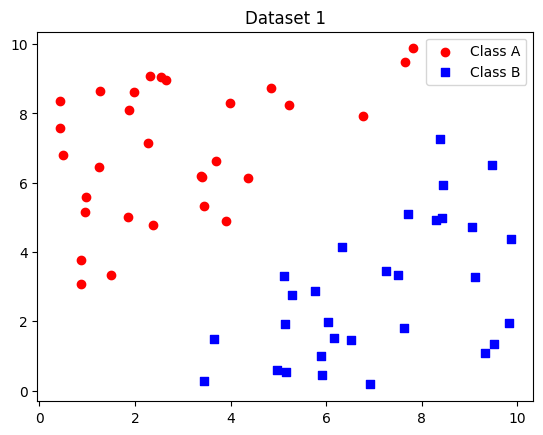

In [305]:
plt.scatter(np.array(data1['A'])[:,0],np.array(data1['A'])[:,1],c='red',label="Class A")
plt.scatter(np.array(data1['B'])[:,0],np.array(data1['B'])[:,1],c='blue',marker='s',label="Class B")
plt.title("Dataset 1")
plt.legend()
plt.show()

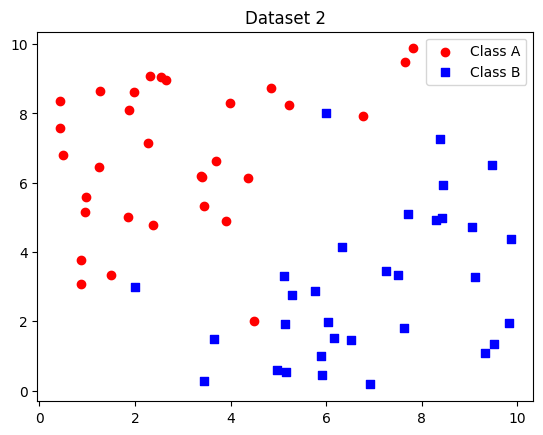

In [306]:
plt.scatter(np.array(data2['A'])[:,0],np.array(data2['A'])[:,1],c='red',label="Class A")
plt.scatter(np.array(data2['B'])[:,0],np.array(data2['B'])[:,1],c='blue',marker='s',label="Class B")
plt.title("Dataset 2")
plt.legend()
plt.show()

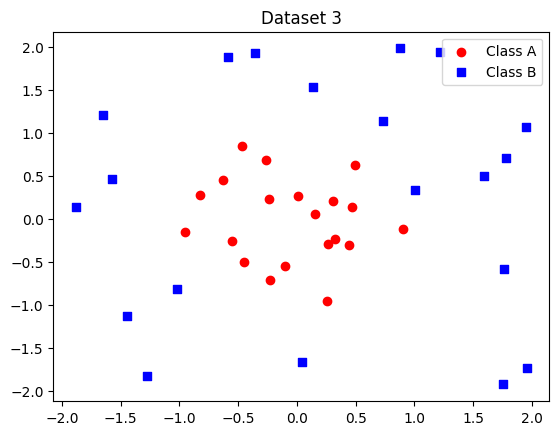

In [307]:
plt.scatter(np.array(data3['A'])[:,0],np.array(data3['A'])[:,1],c='red',label="Class A")
plt.scatter(np.array(data3['B'])[:,0],np.array(data3['B'])[:,1],c='blue',marker='s',label="Class B")
plt.title("Dataset 3")
plt.legend()
plt.show()

# Forming a Pandas DataFrame of all datasets

- Forming Dataframe of Dataset 1

In [319]:
x1=np.array(data1['A'])[:,0]
x2=np.array(data1['A'])[:,1]
x1=np.append(x1,np.array(data1['B'])[:,0])
x2=np.append(x2,np.array(data1['B'])[:,1])
y=np.ones(len(data1['A']))
y=np.append(y,np.full(len(data1['B']),-1))

In [320]:
df1=pd.DataFrame()
df1['x1']=x1
df1['x2']=x2
df1.insert(0,"1",1)
df1['y']=y
df1.head()

,1,x1,x2,y
0,1,0.4952,6.8088,1.0
1,1,2.6505,8.9590,1.0
2,1,3.4403,5.3366,1.0
3,1,3.4010,6.1624,1.0
4,1,5.2153,8.2529,1.0


In [321]:
X1=df1.iloc[:,:-1]
X1.head()

,1,x1,x2
0,1,0.4952,6.8088
1,1,2.6505,8.9590
2,1,3.4403,5.3366
3,1,3.4010,6.1624
4,1,5.2153,8.2529


- Forming Dataframe of Dataset 2

In [325]:
x1=np.array(data2['A'])[:,0]
x2=np.array(data2['A'])[:,1]
x1=np.append(x1,np.array(data2['B'])[:,0])
x2=np.append(x2,np.array(data2['B'])[:,1])
y=np.ones(len(data2['A']))
y=np.append(y,np.full(len(data2['B']),-1))

In [326]:
df2=pd.DataFrame()
df2['x1']=x1
df2['x2']=x2
df2.insert(0,"1",1)
df2['y']=y
df2.head()

,1,x1,x2,y
0,1,0.4952,6.8088,1.0
1,1,2.6505,8.9590,1.0
2,1,3.4403,5.3366,1.0
3,1,3.4010,6.1624,1.0
4,1,5.2153,8.2529,1.0


In [327]:
X2=df2.iloc[:,:-1]
X2.head()

,1,x1,x2
0,1,0.4952,6.8088
1,1,2.6505,8.9590
2,1,3.4403,5.3366
3,1,3.4010,6.1624
4,1,5.2153,8.2529


- Forming Dataframe of Dataset 3

In [328]:
x1=np.array(data3['A'])[:,0]
x2=np.array(data3['A'])[:,1]
x1=np.append(x1,np.array(data3['B'])[:,0])
x2=np.append(x2,np.array(data3['B'])[:,1])
y=np.ones(len(data3['A']))
y=np.append(y,np.full(len(data3['B']),-1))

In [329]:
df3=pd.DataFrame()
df3['x1']=x1
df3['x2']=x2
df3.insert(0,"1",1)
df3['y']=y
df3.head()

,1,x1,x2,y
0,1,0.0113,0.2713,1.0
1,1,0.9018,-0.1121,1.0
2,1,0.2624,-0.2899,1.0
3,1,0.3049,0.2100,1.0
4,1,-0.2255,-0.7156,1.0


In [330]:
X3=df3.iloc[:,:-1]
X3.head()

,1,x1,x2
0,1,0.0113,0.2713
1,1,0.9018,-0.1121
2,1,0.2624,-0.2899
3,1,0.3049,0.2100
4,1,-0.2255,-0.7156


# Checking if a linear classifier exists for each of the Datasets
- Using hard svm solver

In [302]:
def hard_svm_solver(X_data,Y_data):
    w=cp.Variable(X_data.shape[1])
    objective=cp.Minimize(0.5*cp.norm(w[1:],2)**2)
    constraints=[cp.multiply(Y_data,(X_data@w))>=1]
    prob=cp.Problem(objective,constraints)
    prob.solve()
    print(f"Problem Status: {prob.status}")
    if prob.status == 'optimal':
        print("Result: A linear classifier EXISTS.")
        print(f"Hyperplane weights (b  w1  w2): {w.value}")
    return w.value

# For Dataset 1

In [331]:
w1=hard_svm_solver(X1.values,df1["y"].values)

Problem Status: optimal
Result: A linear classifier EXISTS.
Hyperplane weights (b  w1  w2): [ 1.19760763 -0.92288126  0.76271797]


- Linear Classifier exists for Dataset 1
- Plotting the separating and supporting hyperplanes

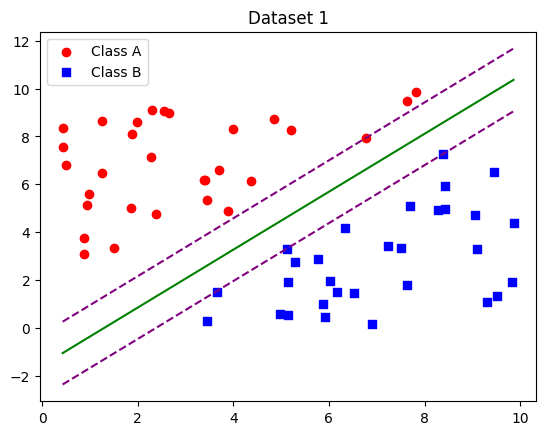

In [332]:
x1_plot=np.linspace(np.min(X1.iloc[:,1]),np.max(X1.iloc[:,1]),100)
x2_plot=(-w1[1]*x1_plot-w1[0])/w1[2]
hyp1=(-w1[1]*x1_plot-w1[0]+1)/w1[2]
hyp2=(-w1[1]*x1_plot-w1[0]-1)/w1[2]
plt.scatter(np.array(data1['A'])[:,0],np.array(data1['A'])[:,1],c='red',label="Class A")
plt.scatter(np.array(data1['B'])[:,0],np.array(data1['B'])[:,1],c='blue',marker='s',label="Class B")
plt.plot(x1_plot,hyp1,c='purple',linestyle='--')
plt.plot(x1_plot,hyp2,c='purple',linestyle='--')
plt.plot(x1_plot,x2_plot,c='green')
plt.title("Dataset 1")
plt.legend()
plt.show()

# For Dataset 2

In [333]:
w2=solver(X2.values,df2["y"].values)

Problem Status: infeasible


- A linear classifier doesn't exist for Dataset 2
- It was a bit evident by looking into the Data2 plot

# For Dataset 3

- It obviously isn't linearly classifiable, by looking at the Data3 plot

In [334]:
w3=solver(X3.values,df3["y"].values)

Problem Status: infeasible


# Only the Dataset 1 was linearly separable
- The Primal Problem was solved earlier to obtain the weights and biases of the separating hyperplane

### Primal Problem


**Optimization Problem:**

$$\min_{w, b} \frac{1}{2} \|w\|^2$$

**Subject to:**

$$y_i (w^T x_i + b) \geq 1, \quad \forall i = 1, \dots, N$$

**Where:**
* $w$ is the weight vector perpendicular to the hyperplane.
* $b$ is the bias term.
* $x_i \in \mathbb{R}^2$ represents the input vectors from datasets A and B.
* $y_i \in \{1, -1\}$ are the labels assigned to the vectors in matrix A and B respectively.

In [350]:
print(f"Weights(w1,w2):{w1[1],w1[2]}")
print(f"Bias(b):{w1[0]}")

Weights(w1,w2):(-0.9228812608216627, 0.7627179748083037)
Bias(b):1.1976076273761878


###  Dual SVM Problem Formulation
.

**Optimization Problem:**

$$\max_{\lambda \geq 0} \left( -\frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \lambda_i \lambda_j \hat{y}_i \hat{y}_j (\hat{x}_i)^\top \hat{x}_j + \sum_{i=1}^{N} \lambda_i \right)$$

**Subject to:**

$$\sum_{i=1}^{N} \lambda_i \hat{y}_i = 0$$
$$0 \leq \lambda_i, \quad \forall i \in [N]$$

---

### All KKT Conditions for SVM

For the primal optimal solution $(w^*, b^*)$ and dual optimal solution $\lambda^*$ to be valid, the following Karush-Kuhn-Tucker (KKT) conditions must be satisfied:

1. **Dual Feasibility & Stationarity:**
   $$\lambda_i^* \geq 0, \quad \sum_{i=1}^{N} \lambda_i^* \hat{y}_i = 0$$

2. **Primal Feasibility:**
   $$1 - \hat{y}_i \left( (w^*)^\top \hat{x}_i + b^* \right) \leq 0, \quad \forall i \in [N]$$

3. **Complementary Slackness:**
   $$\lambda_i^* \left[ 1 - \hat{y}_i \left( (w^*)^\top \hat{x}_i + b^* \right) \right] = 0, \quad \forall i \in [N]$$

4. **Optimal Weight Vector Relationship:**
   $$w^* = \sum_{i=1}^{N} \lambda_i^* \hat{y}_i \hat{x}_i$$


# Solving the Dual Problem for Dataset 1 and verifying the KKT Conditions

In [351]:
def solve_dual(X_data,Y_data):
    alpha=cp.Variable(X_data.shape[0])
    Y_labels = Y_data.reshape(-1, 1)
    Q=(Y_labels@Y_labels.T)*(X_data@X_data.T)
    objective=cp.Maximize(cp.sum(alpha)-0.5*cp.quad_form(alpha,cp.psd_wrap(Q)))
    constraints=[alpha>=0,
    cp.sum(cp.multiply(alpha,Y_data))==0]
    prob=cp.Problem(objective,constraints)
    prob.solve()
    print(f"Problem Status: {prob.status}")
    if prob.status == 'optimal':
        print("Solved Dual Problem!")
        print(f"Alpha:{alpha.value}")
    return alpha.value

In [352]:
alpha1=solve_dual(X1.values[:,1:],df1["y"].values)

Problem Status: optimal
Solved Dual Problem!
Alpha:[-4.38255575e-20 -2.07816770e-20 -2.20209059e-20 -2.15785505e-20
 -9.20009973e-21 -2.16097927e-21 -8.23178809e-20 -1.52181726e-20
 -4.77575746e-20 -2.79202574e-20 -1.62068210e-20 -2.47026246e-20
 -4.06391495e-20 -1.32617059e-20 -3.37988625e-20 -1.85036244e-20
 -2.12765056e-21 -1.06359031e-20  7.16724265e-01 -3.95165270e-20
 -1.15357044e-19 -2.17957358e-20 -2.09405295e-20 -2.11628385e-20
 -9.03212603e-20 -2.69142548e-20 -5.89413661e-20 -5.19001129e-20
 -3.83465987e-20 -2.84011607e-20 -1.06262321e-20 -5.75156504e-21
 -7.31023570e-21  7.19256214e-21 -6.25721402e-21 -1.75428320e-20
 -7.52409897e-21 -2.29130503e-20 -1.87023957e-20 -2.02403285e-20
 -5.61887570e-21 -7.89892875e-21 -1.74889452e-20 -4.11710864e-21
 -9.13734026e-21 -1.38038036e-20 -2.40180403e-20  7.03842478e-02
 -1.12400531e-20 -4.21121627e-21 -1.69056537e-20  6.46340017e-01
 -4.28913550e-21 -8.45273955e-21 -1.36678879e-20 -1.89434243e-20
 -1.93735141e-20 -2.02863771e-20 -1.810

In [353]:
def check_KKT(w_primal,alpha_dual,X_data,Y_data):
    check=True
    if((alpha_dual>=-1e-5).all() and np.abs(np.sum(alpha_dual*Y_data))<1e-5):
        print("Passed 1st KKT condition")
    else:
        print("Failed 1st KKT condition")
        check=False
    if(((1-Y_data*(X_data@w_primal))<=1e-5).all()):
        print("Passed 2nd KKT condition")
    else:
        print("Failed 2nd KKT condition")
        check=False
    if((np.abs((alpha_dual*(1-Y_data*(X_data@w_primal))))<=1e-5).all()):
        print("Passed 3rd KKT condition")
    else:
        print("Failed 3rd KKT condition")
        check=False
    w_dual=np.sum(alpha_dual.reshape(-1,1)*Y_data.reshape(-1,1)*X1.values[:,1:],axis=0)
    if(w_dual.any()==w_primal[1:].all()):
        print("Passed 4th KKT condition")
    else:
        print("Failed 4th KKT Condition")
        check=False
    if(check):
        print("Verified all the KKT Conditions!")

In [354]:
check_KKT(w1,alpha1,X1.values,df1["y"].values)

Passed 1st KKT condition
Passed 2nd KKT condition
Passed 3rd KKT condition
Passed 4th KKT condition
Verified all the KKT Conditions!


# Creating a relaxed SVM(Soft Margin SVM) solver function

In [356]:
def relaxed_solver(X_data,Y_data,C=1.0):
    w=cp.Variable(X_data.shape[1])
    zeta=cp.Variable(X_data.shape[0])
    objective=cp.Minimize(0.5*cp.norm(w[1:],2)**2+C*cp.sum(zeta))
    constraints=[cp.multiply(Y_data,(X_data@w))>=1-zeta,
                 zeta>=0]
    prob=cp.Problem(objective,constraints)
    prob.solve()
    print(f"Problem Status: {prob.status}")
    if prob.status == 'optimal':
        print("Result: A linear classifier EXISTS in case of relaxed SVM.")
        print(f"Hyperplane weights (b  w1  w2): {w.value}")
    return w.value,np.sum((zeta.value)>1),np.sum((zeta.value)>1e-3)

# Using relaxed SVM solver to solve  dataset 2

In [357]:
w2,outliers2,allout2=relaxed_solver(X2.values,df2["y"].values,C=1)

Problem Status: optimal
Result: A linear classifier EXISTS in case of relaxed SVM.
Hyperplane weights (b  w1  w2): [ 0.08310634 -0.57343902  0.55902731]


In [358]:
print("No. of outliers in Dataset 2:",outliers2)

No. of outliers in Dataset 2: 3


In [359]:
print("No. of outliers in Dataset 2 including correctly classified points that fall inside the margin:",allout2)

No. of outliers in Dataset 2 including correctly classified points that fall inside the margin: 6


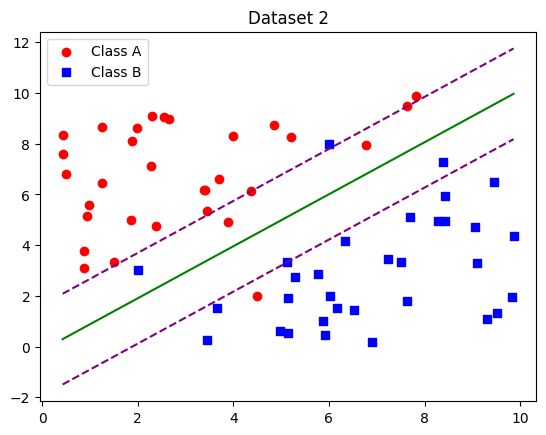

In [360]:
x1_plot=np.linspace(np.min(X2.iloc[:,1]),np.max(X2.iloc[:,1]),100)
x2_plot=(-w2[1]*x1_plot-w2[0])/w2[2]
hyp1=(-w2[1]*x1_plot-w2[0]+1)/w2[2]
hyp2=(-w2[1]*x1_plot-w2[0]-1)/w2[2]
plt.scatter(np.array(data2['A'])[:,0],np.array(data2['A'])[:,1],c='red',label="Class A")
plt.scatter(np.array(data2['B'])[:,0],np.array(data2['B'])[:,1],c='blue',marker='s',label="Class B")
plt.plot(x1_plot,hyp1,c='purple',linestyle='--')
plt.plot(x1_plot,hyp2,c='purple',linestyle='--')
plt.plot(x1_plot,x2_plot,c='green')
plt.legend()
plt.title("Dataset 2")
plt.show()

# Trying to solve relaxed SVM to solve dataset 3

In [361]:
w3,outliers3,allout3=relaxed_solver(X3.values,df3["y"].values,C=1)

Problem Status: optimal
Result: A linear classifier EXISTS in case of relaxed SVM.
Hyperplane weights (b  w1  w2): [ 0.51444471 -0.6636139  -0.46941077]


In [362]:
print("No. of outliers in Dataset 3:",outliers3)

No. of outliers in Dataset 3: 12


In [363]:
print("No. of outliers in Dataset 3 including correctly classified points that fall inside the margin:",allout3)

No. of outliers in Dataset 3 including correctly classified points that fall inside the margin: 32


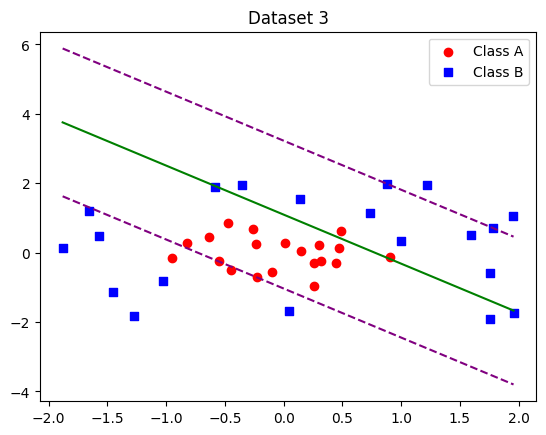

In [364]:
x1_plot=np.linspace(np.min(X3.iloc[:,1]),np.max(X3.iloc[:,1]),100)
x2_plot=(-w3[1]*x1_plot-w3[0])/w3[2]
hyp1=(-w3[1]*x1_plot-w3[0]+1)/w3[2]
hyp2=(-w3[1]*x1_plot-w3[0]-1)/w3[2]
plt.scatter(np.array(data3['A'])[:,0],np.array(data3['A'])[:,1],c='red',label="Class A")
plt.scatter(np.array(data3['B'])[:,0],np.array(data3['B'])[:,1],c='blue',marker='s',label="Class B")
plt.plot(x1_plot,hyp1,c='purple',linestyle='--')
plt.plot(x1_plot,hyp2,c='purple',linestyle='--')
plt.plot(x1_plot,x2_plot,c='green')
plt.legend()
plt.title("Dataset 3")
plt.show()

- Very evidently, the number of outliers when relaxed SVM is used to find the separating hyperplanes is too large.
- Hence, Kernels are to be used

### Gaussian Kernel 

Using the Kernel Trick for nonlinear classification

**Gaussian Kernel Function:**

$$K(x, y) = e^{(-\gamma\|x-y\|_2^2)}$$

**Parameters:**
* **$\gamma \in \{0.1, 1, 10\}$**: The kernel coefficient that defines how far the influence of a single training example reaches.
* **$\|x-y\|_2^2$**: The squared Euclidean distance (L2 norm) between the input vectors.

In [366]:
def gaussian_kernel(X_data,Y_data,C=1.0,gamma=0.1):
    alpha=cp.Variable(X_data.shape[0])
    K=np.zeros((X_data.shape[0],X_data.shape[0]))
    for i in range(X_data.shape[0]):
        for j in range(X_data.shape[0]):
            K[i,j]=np.exp(-gamma*np.sum((X_data[i]-X_data[j])**2))
    Y_values=Y_data.reshape(-1,1)
    Q=(Y_values@Y_values.T)*K
    objective=cp.Maximize(cp.sum(alpha)-0.5*cp.quad_form(alpha,cp.psd_wrap(Q)))
    constraints=[alpha>=0,
                 alpha<=C,
                 cp.sum(cp.multiply(alpha,Y_data))==0]
    prob=cp.Problem(objective,constraints)
    prob.solve()
    print(f"Problem Status: {prob.status}")
    if prob.status == 'optimal':
        print("Solved Using the Gaussian Kernel!")
        print(f"Alpha for gamma={gamma}:{alpha.value}")
    return alpha.value

In [374]:
alpha={}
alpha['0.1']=gaussian_kernel(X3.values[:,1:],df3["y"].values,C=1,gamma=0.1)
alpha['1']=gaussian_kernel(X3.values[:,1:],df3["y"].values,C=1,gamma=1)
alpha['10']=gaussian_kernel(X3.values[:,1:],df3["y"].values,C=1,gamma=10)

Problem Status: optimal
Solved Using the Gaussian Kernel!
Alpha for gamma=0.1:[ 1.00000000e+00  1.00000000e+00  2.75283143e-21  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  4.73386170e-01 -4.21068902e-21  1.00000000e+00  1.00000000e+00
  1.00000000e+00 -2.16198382e-21  6.97963041e-01  1.18514775e-21
  6.74638460e-21  1.00000000e+00  1.00000000e+00  6.26414304e-21
  2.65210864e-01  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  9.06138348e-01  1.00000000e+00 -5.30675063e-22  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.03528651e-21  1.00000000e+00]
Problem Status: optimal
Solved Using the Gaussian Kernel!
Alpha for gamma=1:[-1.61033408e-22  1.00000000e+00  4.11442017e-22 -2.81959170e-22
  8.78682391e-01  1.00000000e+00  5.18879624e-22 -7.27884075e-22
  2.67503451e-01  1.00000000e+00 -6.60650294e-22  6.75317999e-01


In [392]:
def plot_grid(X_data,Y_data,alpha,gamma=0.1,C=1):
    epsilon = 1e-5
    indices_k = np.where((alpha > epsilon) & (alpha < C - epsilon))[0]
    
    k = indices_k[0]
    
    # calculating (w*)^T phi(x_k) using the kernel
    w_phi_xk = 0
    for i in range(len(alpha)):
        if alpha[i] > epsilon: # Only need support vectors
            dist_sq = np.sum((X_data[i] - X_data[k])**2)
            kernel_val = np.exp(-gamma * dist_sq)
            w_phi_xk += alpha[i] * Y_data[i] * kernel_val
    
    # b* = y_k - (w*)^T phi(x_k)
    bias = Y_data[k] - w_phi_xk


    res = 0.1
    x_range = np.arange(-2, 12 + res, res)
    y_range = np.arange(-2, 12 + res, res)
    
    #creating the grid
    xx, yy = np.meshgrid(x_range, y_range)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    #predicting labels for all points in the grid
    Z = []
    for p in grid_points:
        sv_idx = np.where(alpha > 1e-5)[0]
        score = bias
        for idx in sv_idx:
            dist_sq = np.sum((X_data[idx] - p)**2)
            score += alpha[idx] * Y_data[idx] * np.exp(-gamma * dist_sq)
        
        Z.append(1 if score >= 0 else -1)
    
    Z = np.array(Z).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    
    plt.pcolormesh(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3, shading='auto')
    
    #plotting original datapoints
    plt.scatter(X_data[Y_data == 1, 0], X_data[Y_data == 1, 1], 
                c='blue', edgecolors='k', label='+1 labelled Datapoints')
    plt.scatter(X_data[Y_data == -1, 0], X_data[Y_data == -1, 1], 
                c='red', edgecolors='k', label='-1 labelled Datapoints')

    plt.title(f"Nonlinear SVM Classification (gamma={gamma})")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(-2, 12)
    plt.ylim(-2, 12)
    plt.legend()
    plt.show()

Taking C=1 for all plots


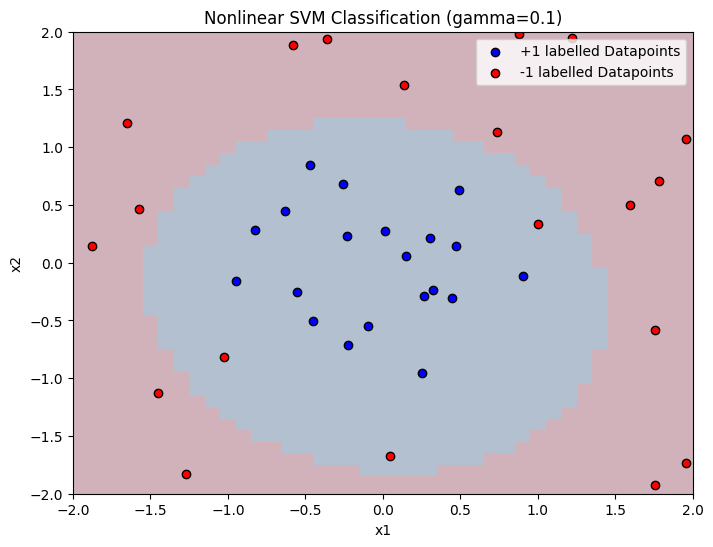

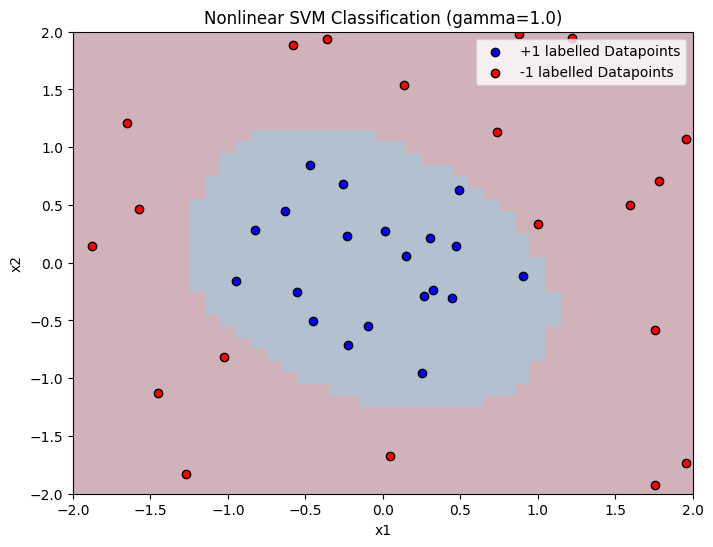

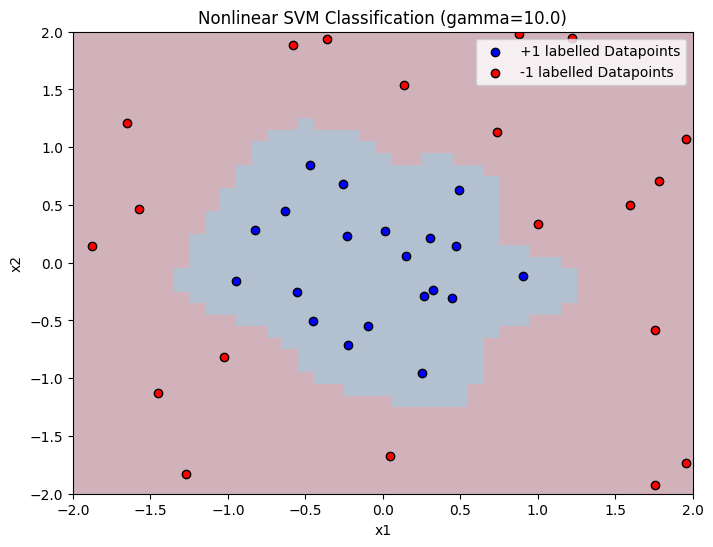

In [376]:
print("Taking C=1 for all plots")
for g in alpha.keys():
    plot_grid(X3.values[:,1:],df3["y"].values,alpha[g],gamma=float(g),C=1)

- From the different non linear boundaries for different values of gamma and C, it can be clearly deduced that:
- For a higher Gamma, the generalisation is decreased.
- The curve tends to overfit on gamma=10, whereas there are a few misclassified points in gamma=0.1
- The curve is generalised and correctly classified for gamma=1
- A higher value of C, penalises the misclassified points more!